# CAD/USD forecasting: data exploration

`data.py` is the reusable data layer. This notebook is the human-friendly entry point: it loads the FRED data, checks the registered series, visualises the target and covariate, and creates a historical cutoff context.

This first notebook does not train a model or call an agent. The next notebook will add traditional forecasting baselines.

In [6]:
from datetime import datetime, timezone
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'aieng-forecasting').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from implementations.cad_usd_forecasting.data import build_cadusd_service

DATA_AS_OF = datetime.now(tz=timezone.utc).replace(tzinfo=None)
print('Repository root:', ROOT)
print('Direct-read cutoff:', DATA_AS_OF.date())

Repository root: /home/coder/development/agentic-forecasting
Direct-read cutoff: 2026-09-17


## 1. Build the data service

The service registers three targets:

- `cadusd_logret_1b`: next business day
- `cadusd_logret_5b`: next five business days
- `cadusd_logret_21b`: next twenty-one business days

It also registers `wti_log_ret_1b_l1b`, a one-business-day-lagged WTI return covariate. The FRED key is loaded from the repository-root `.env`.

In [7]:
svc = build_cadusd_service(
    start='1990-01-01',
    include_covariates=True,
)

print('Registered series:')
for series_id in svc.series_ids:
    print(' -', series_id)

Registered series:
 - cadusd_logret_1b
 - cadusd_logret_21b
 - cadusd_logret_5b
 - wti_log_ret_1b_l1b


## 2. Inspect the target data

A log-return target measures relative movement rather than the exchange-rate level:

$$r_t = \log(x_t / x_{t-N})$$

For example, a value near `0.003` represents approximately a `0.3%` increase in USD/CAD over the selected horizon.

In [8]:
target_id = 'cadusd_logret_1b'
target = svc.get_series(target_id, as_of=DATA_AS_OF)
target['timestamp'] = pd.to_datetime(target['timestamp'])

print(target.head())
print('Rows:', len(target))
print('Date range:', target['timestamp'].min().date(), 'to', target['timestamp'].max().date())

   timestamp     value released_at
0 1990-01-03  0.000689  1990-01-03
1 1990-01-04  0.000086  1990-01-04
2 1990-01-05 -0.001206  1990-01-05
3 1990-01-08  0.000086  1990-01-08
4 1990-01-09  0.001120  1990-01-09
Rows: 9194
Date range: 1990-01-03 to 2026-08-21


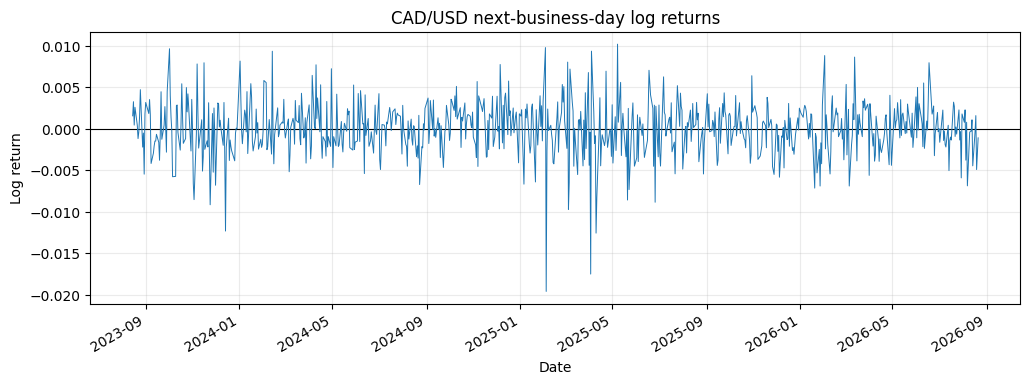

In [9]:
recent = target.tail(756)
fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, color='black', linewidth=0.8)
ax.plot(recent['timestamp'], recent['value'], linewidth=0.7)
ax.set_title('CAD/USD next-business-day log returns')
ax.set_ylabel('Log return')
ax.set_xlabel('Date')
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.show()

## 3. Inspect a covariate

A covariate is an input that may help explain or predict the target. WTI is included because Canadian dollar movements can be related to commodity and energy prices. The `_l1b` suffix means the feature is lagged by one business day to reduce look-ahead leakage.

   timestamp     value released_at
0 1990-01-04  0.039842  1990-01-04
1 1990-01-05 -0.016942  1990-01-05
2 1990-01-08 -0.014630  1990-01-08
3 1990-01-09 -0.063990  1990-01-09
4 1990-01-10  0.027799  1990-01-10


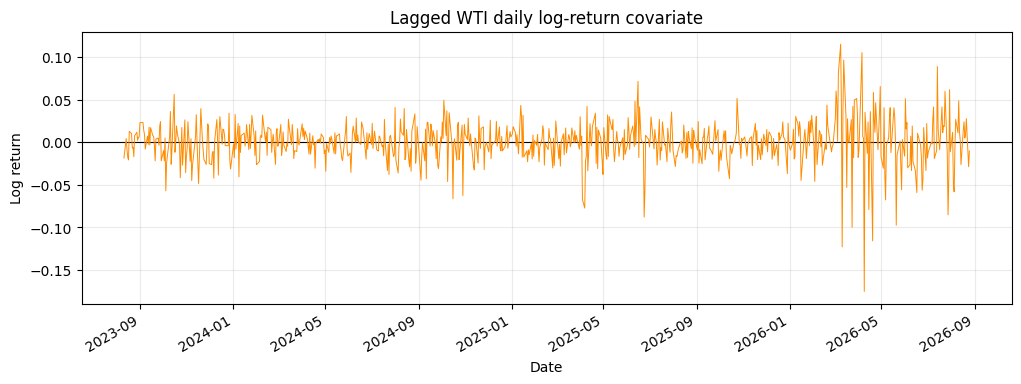

In [10]:
wti = svc.get_series('wti_log_ret_1b_l1b', as_of=DATA_AS_OF)
wti['timestamp'] = pd.to_datetime(wti['timestamp'])
print(wti.head())

fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, color='black', linewidth=0.8)
ax.plot(wti.tail(756)['timestamp'], wti.tail(756)['value'], linewidth=0.7, color='darkorange')
ax.set_title('Lagged WTI daily log-return covariate')
ax.set_ylabel('Log return')
ax.set_xlabel('Date')
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.show()

## 4. Create a historical forecast context

A forecast origin is the date when the forecast is made. `ForecastContext` ensures a model only receives information available up to that `as_of` date. This is the same cutoff discipline used by the S&P 500 project.

In [11]:
as_of = pd.Timestamp('2025-01-15')
context = svc.context(as_of=as_of)

print('Forecast origin:', as_of.date())
print('Target rows visible:', len(context.get_series('cadusd_logret_1b')))
print('Latest visible target date:', pd.to_datetime(context.get_series('cadusd_logret_1b')['timestamp']).max().date())

Forecast origin: 2025-01-15
Target rows visible: 8793
Latest visible target date: 2025-01-15


## Next step

Start with traditional baselines: naive, exponential smoothing or ARIMA, then LightGBM with the WTI covariate. Evaluate each model at the same historical forecast origins before adding the news-aware agent.